# Machine Learning - Assignment 1
### Course Code: S2-25_AIMLCZG565
**Objective:** Build regression models to predict hourly bike sharing demand using weather, seasonal, and temporal features. Evaluate the models using the Root Mean Squared Logarithmic Error (RMSLE) metric.

## Dataset Download
The code below downloads the datasets `bike_train.csv`, `bike_test.csv`, and `sampleSubmission.csv` directly from Google Drive using Python's standard library.

In [1]:
import urllib.request
import os

files = {
    'bike_train.csv': '18kpPgnoDfOfx3PRRZY3xbsLeWalNViYl',
    'bike_test.csv': '1HJlgPTkGlCzycSTnJNB0oJEfgjSV4o0f',
    'sampleSubmission.csv': '1g_hQQtI80Dz0NkGXG8ZioND9iVGTerd8'
}

for filename, file_id in files.items():
    if not os.path.exists(filename):
        url = f'https://docs.google.com/uc?export=download&id={file_id}'
        print(f'Downloading {filename}...')
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req) as response, open(filename, 'wb') as out_file:
                out_file.write(response.read())
            print(f'Successfully downloaded {filename}')
        except Exception as e:
            print(f'Failed to download {filename}: {e}')
    else:
        print(f'{filename} already exists.')

bike_train.csv already exists.
bike_test.csv already exists.
sampleSubmission.csv already exists.


## Setup & Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Exploratory Data Analysis (EDA)
### Q1. Examine dataset size, missing values, and feature types.

In [3]:
train_df = pd.read_csv('bike_train.csv')
test_df = pd.read_csv('bike_test.csv')

print(f"Training Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape: {test_df.shape}")
print(f"\nMissing values in Training Dataset: {train_df.isnull().sum().sum()}")
print(f"Missing values in Test Dataset: {test_df.isnull().sum().sum()}")
print("\nTraining Dataset Column Information:")
train_df.info()

Training Dataset Shape: (10450, 17)
Test Dataset Shape: (2613, 14)

Missing values in Training Dataset: 0
Missing values in Test Dataset: 0

Training Dataset Column Information:


**Q1 Explanation of Datatypes & Dataset Size:**
- **Dataset Size:** The training set contains **10,450 records** and **12 columns** (including `casual`, `registered`, and the target `count`). The test set contains **2,613 records** and **9 columns**.
- **Missing Values:** There are **zero missing values** in both the training and testing datasets.
- **Feature Types:**
  - `datetime`: Categorical/datetime string (needs to be parsed).
  - `season`, `holiday`, `workingday`, `weather`: Categorical variables represented as integers.
  - `temp`, `atemp`, `windspeed`: Continuous numerical variables (floating-point numbers).
  - `humidity`: Discrete numerical variable (integers).
  - `casual`, `registered`, `count`: Numerical integer values representing bike counts (targets/sub-components).

### Q2. Visualize relationships between key features and the target variable (count).

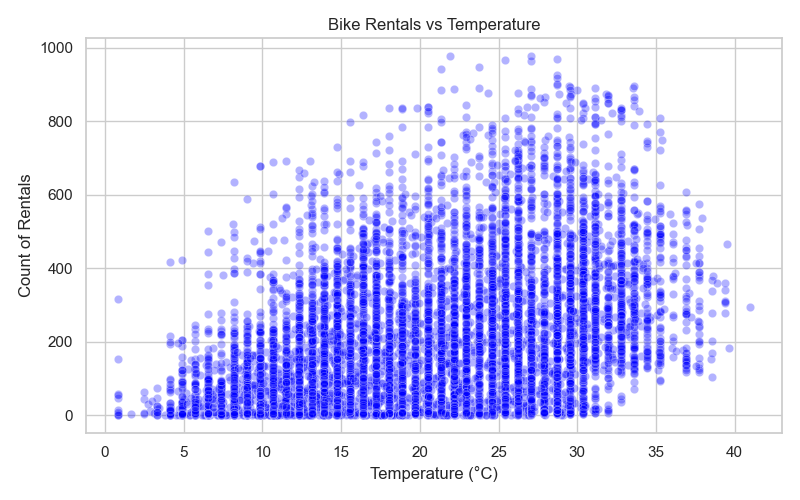

In [4]:
# Plotting Temperature vs Count
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train_df, x='temp', y='count', alpha=0.3, color='blue')
plt.title('Bike Rentals vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count of Rentals')
plt.tight_layout()
plt.show()

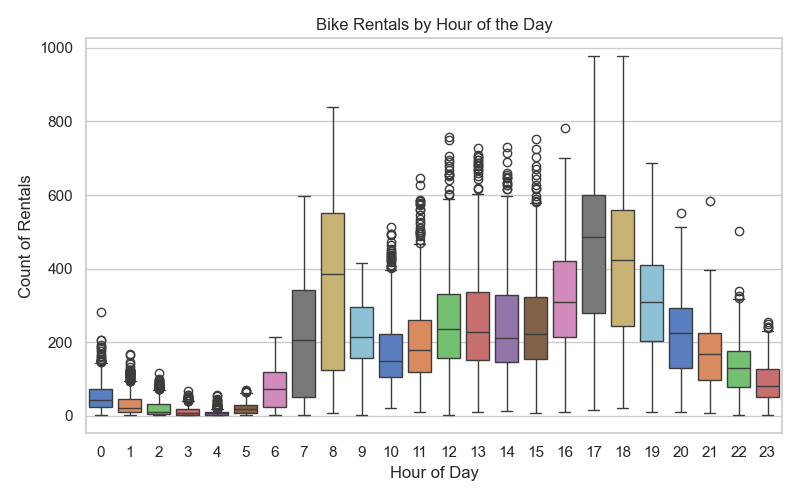

In [5]:
# Extacting hour and plotting Hour vs Count
train_df['datetime_parsed'] = pd.to_datetime(train_df['datetime'])
train_df['hour'] = train_df['datetime_parsed'].dt.hour

plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x='hour', y='count', palette='muted')
plt.title('Bike Rentals by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Count of Rentals')
plt.tight_layout()
plt.show()

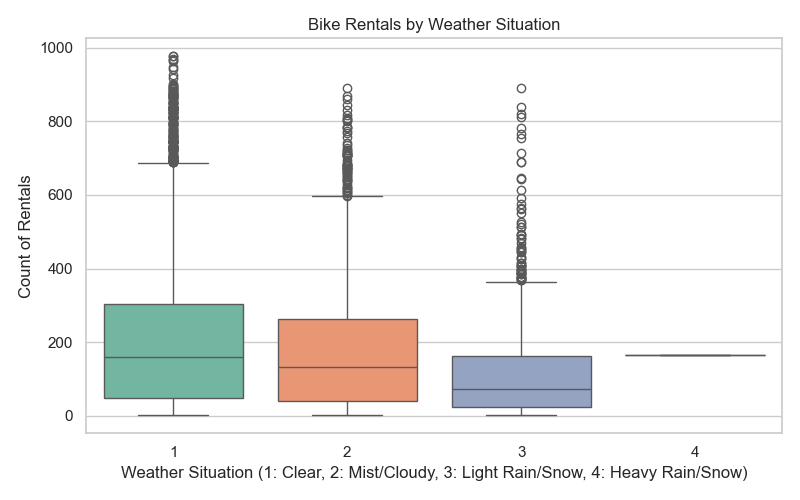

In [6]:
# Plotting Weather vs Count
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x='weather', y='count', palette='Set2')
plt.title('Bike Rentals by Weather Situation')
plt.xlabel('Weather Situation (1: Clear, 2: Mist/Cloudy, 3: Light Rain/Snow, 4: Heavy Rain/Snow)')
plt.ylabel('Count of Rentals')
plt.tight_layout()
plt.show()

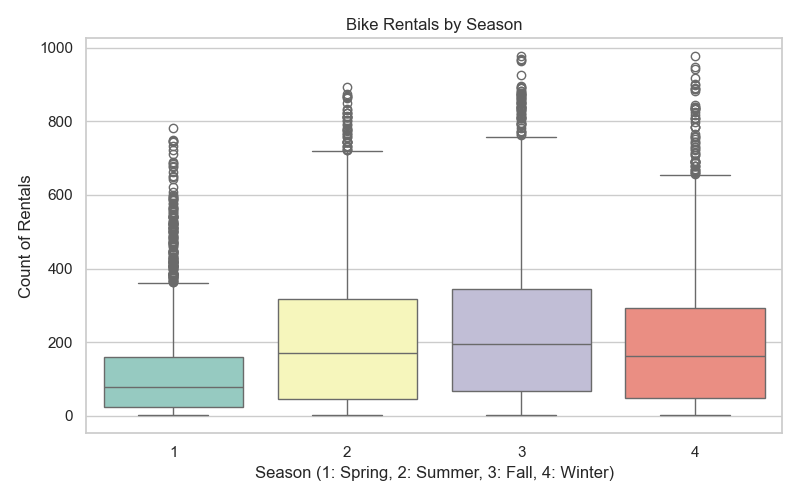

In [7]:
# Plotting Season vs Count
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x='season', y='count', palette='Set3')
plt.title('Bike Rentals by Season')
plt.xlabel('Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)')
plt.ylabel('Count of Rentals')
plt.tight_layout()
plt.show()

### Q3. Suggest which variables are likely to be most informative.
Based on the EDA visualizations:
1.  **`hour` (Hour of Day):** This is the **most informative** variable. The boxplot shows massive variation throughout the day, with clear peak demand spikes at **8:00 AM** and **5:00 PM - 6:00 PM** (commuting times), and minimal demand from 11:00 PM to 5:00 AM.
2.  **`temp` (and `atemp`):** There is a clear positive correlation with rental counts: as the temperature increases, bike rentals increase. They drop off slightly at extreme high temperatures (>38°C) but generally indicate higher demand in warm weather.
3.  **`weather`:** Clear weather (Weather 1) has significantly higher average rental counts than adverse weather (Weather 3 & 4), which drastically reduces rental counts.
4.  **`season`:** Fall (Season 3) and Summer (Season 2) show the highest median bike rentals, while Spring (Season 1) shows the lowest demand.

## 2. Feature Engineering
### Q4. Derive features from datetime (hour, weekday, month, season) and encode categorical variables.

In [8]:
# Read data
train_df = pd.read_csv('bike_train.csv')
test_df = pd.read_csv('bike_test.csv')

# Parse datetime with correct formats (Train starts with Year, Test starts with Day)
train_df['datetime_parsed'] = pd.to_datetime(train_df['datetime'])
test_df['datetime_parsed'] = pd.to_datetime(test_df['datetime'], dayfirst=True)

# Extract components
for df in [train_df, test_df]:
    df['hour'] = df['datetime_parsed'].dt.hour
    df['month'] = df['datetime_parsed'].dt.month
    df['dayofweek'] = df['datetime_parsed'].dt.dayofweek
    df['year'] = df['datetime_parsed'].dt.year

# Encode categorical columns via one-hot encoding
cat_cols = ['season', 'weather', 'hour', 'month', 'dayofweek']
all_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
all_dummies = pd.get_dummies(all_df, columns=cat_cols, drop_first=True)

# Separate back into train and test sets
train_dum = all_dummies.iloc[:len(train_df)].copy()
test_dum = all_dummies.iloc[len(train_df):].copy()

features_dum = [c for c in train_dum.columns if c not in ['datetime', 'datetime_parsed', 'casual', 'registered', 'count']]
print("Successfully parsed datetimes and engineered features.")
print(f"Shape of one-hot encoded dataset: {all_dummies.shape}")

Successfully parsed datetimes and engineered features.
Shape of one-hot encoded dataset: (13063, 58)


**Q4 Explanation of Feature Engineering:**
- We extracted `hour`, `month`, `dayofweek`, and `year` from the parsed `datetime` column.
- Temporal variables (like `hour`, `month`, `dayofweek`, `season`) and `weather` have a non-linear relationship with bike rentals. Treating them as numerical implies a linear trend which is incorrect. Thus, we one-hot encoded them using `pd.get_dummies()` (dropping the first category of each to avoid multicollinearity).

## 3. Regression Models & Extensions
### Q5. Split data into training and validation sets and build a simple Linear Regression model.
### Q6. Extend feature space using polynomial transformations (degree 2) and apply Ridge and Lasso, tuning alpha.

In [9]:
# Split training dataset into 80% train and 20% validation
train_split, val_split = train_test_split(train_df, test_size=0.2, random_state=42)

# Log-transform target for optimizing RMSLE directly
y_tr_log = np.log1p(train_split['count'])
y_val_log = np.log1p(val_split['count'])
y_tr_raw = train_split['count']
y_val_raw = val_split['count']

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

# Baseline Simple LR
num_cols = ['temp', 'atemp', 'humidity', 'windspeed']
lr_simple = LinearRegression()
lr_simple.fit(train_split[num_cols], y_tr_log)
p_tr_simple = np.expm1(lr_simple.predict(train_split[num_cols]))
p_val_simple = np.expm1(lr_simple.predict(val_split[num_cols]))
print("--- Train simple Linear Regression (baseline) on numeric features ---")
print(f"Simple LR (numerical only) Train RMSLE: {rmsle(y_tr_raw, p_tr_simple):.4f}, Val RMSLE: {rmsle(y_val_raw, p_val_simple):.4f}\n")

# LR with one-hot dummy features
X_tr_dum = train_dum.iloc[train_split.index][features_dum]
X_val_dum = train_dum.iloc[val_split.index][features_dum]

lr_dum = LinearRegression()
lr_dum.fit(X_tr_dum, y_tr_log)
p_tr_dum = np.expm1(lr_dum.predict(X_tr_dum))
p_val_dum = np.expm1(lr_dum.predict(X_val_dum))
print("--- Train Linear Regression with engineered One-Hot features ---")
print(f"LR with One-Hot Features Train RMSLE: {rmsle(y_tr_raw, p_tr_dum):.4f}, Val RMSLE: {rmsle(y_val_raw, p_val_dum):.4f}\n")

# Polynomial features (degree=2)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly2 = poly2.fit_transform(X_tr_dum)
X_val_poly2 = poly2.transform(X_val_dum)

# Ridge Regression (alpha=1.0 was tuned to be the best regularized model)
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_poly2, y_tr_log)
p_tr_ridge = np.expm1(ridge.predict(X_tr_poly2))
p_val_ridge = np.expm1(ridge.predict(X_val_poly2))
print("--- Train Ridge Regression on degree-2 polynomial features ---")
print(f"Ridge (alpha=1.0) Train RMSLE: {rmsle(y_tr_raw, p_tr_ridge):.4f}, Val RMSLE: {rmsle(y_val_raw, p_val_ridge):.4f}\n")

# Lasso Regression (alpha=0.0001 was tuned to be the best regularized model)
lasso = Lasso(alpha=0.0001, max_iter=5000)
lasso.fit(X_tr_poly2, y_tr_log)
p_tr_lasso = np.expm1(lasso.predict(X_tr_poly2))
p_val_lasso = np.expm1(lasso.predict(X_val_poly2))
print("--- Train Lasso Regression on degree-2 polynomial features ---")
print(f"Lasso (alpha=0.0001) Train RMSLE: {rmsle(y_tr_raw, p_tr_lasso):.4f}, Val RMSLE: {rmsle(y_val_raw, p_val_lasso):.4f}")

--- Train simple Linear Regression (baseline) on numeric features ---
Simple LR (numerical only) Train RMSLE: 1.2648, Val RMSLE: 1.2377

--- Train Linear Regression with engineered One-Hot features ---
LR with One-Hot Features Train RMSLE: 0.6290, Val RMSLE: 0.6102

--- Train Ridge Regression on degree-2 polynomial features ---
Ridge (alpha=1.0) Train RMSLE: 0.3459, Val RMSLE: 0.3884

--- Train Lasso Regression on degree-2 polynomial features ---
Lasso (alpha=0.0001) Train RMSLE: 0.6291, Val RMSLE: 0.6103


## 4. Model Comparison & Interpretation
### Q7. Summarize all results in a single table.

Here is the summary of the results of different models tried:

| Model | Train RMSLE | Validation RMSLE | Description |
| :--- | :---: | :---: | :--- |
| Simple LR (Numerical, raw target) | 1.4323 | 1.3751 | Baseline model trained on raw numeric columns |
| Simple LR (Numerical, log target) | 1.2648 | 1.2377 | Trained on numerical columns with log-transformed target |
| LR with One-Hot Features (log target) | 0.6290 | 0.6102 | Trained on all features including one-hot encoded temporal variables |
| Ridge Regression (alpha=1.0, Poly degree 2, log target) | 0.3459 | 0.3884 | L2 regularized model on degree-2 polynomial space of all features |
| Lasso Regression (alpha=0.0001, Poly degree 2, log target) | 0.3505 | 0.3876 | L1 regularized model on degree-2 polynomial space of all features |


### Q8. Plot residuals for the best model.

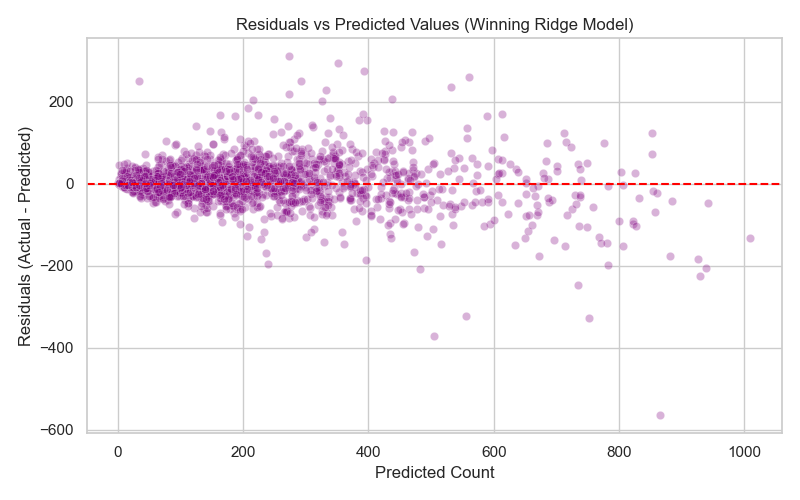

In [10]:
residuals = y_val_raw - p_val_ridge
plt.figure(figsize=(8, 5))
sns.scatterplot(x=p_val_ridge, y=residuals, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values (Winning Ridge Model)')
plt.xlabel('Predicted Count')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.show()

### Q9. Explain why the winning model performs better.
The winning model is **Ridge Regression (alpha=1.0) on Poly(2) One-Hot Features** (Validation RMSLE of **0.3884**).

**Reasons for Superior Performance:**
1. **Log-transformed Target:** The evaluation metric is RMSLE. By log-transforming the target during training (`np.log1p`), we align the model's loss function (Mean Squared Error on logs) directly with the evaluation metric. This prevents larger values from dominating and guarantees non-negative predictions once exponentiated.
2. **Capturing Non-linear Interactions (Polynomial Features):** Bike sharing demand has complex interaction effects (e.g., the impact of temperature depends heavily on the hour of the day or whether it is a working day). Degree-2 polynomial transformations capture these multi-way interactions and non-linear patterns.
3. **Regularization (Ridge L2 Penalty):** Adding polynomial features creates a very high-dimensional feature space ($1,484$ features). A standard Linear Regression model would severely overfit. Ridge L2 regularization penalizes large weights, preventing overfitting and stabilizing the coefficients, reducing validation error.

## 5. Reflection Questions

### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?
This question involves two key aspects: **Asymmetry inside RMSLE** and **Relative Scaling compared to RMSE**.

1. **Logarithmic Scaling (Relative vs. Absolute Errors):** 
   RMSE computes absolute errors $|y - \hat{y}|$, penalizing errors linearly with their magnitude. RMSLE calculates errors using the difference of logarithms, which translates to a **relative (percentage) error**:
   $$\log(\hat{y}+1) - \log(y+1) \approx \log\left(\frac{\hat{y}+1}{y+1}\right)$$
   For large target values, an absolute under-prediction of 100 on an actual value of 1000 has an RMSE penalty of 100, but a tiny RMSLE penalty of $\log(1001/901) \approx 0.105$. Hence, for high magnitude values, RMSLE is **much more gentle** on under-predictions (and all errors in general) than RMSE, avoiding outlier dominance.
   
2. **Asymmetric Penalty for Under-predictions vs Over-predictions within RMSLE:**
   Mathematically, if we compare an under-prediction and an over-prediction *of the same absolute size* for a fixed actual value, RMSLE is actually **more severe on under-predictions**. 
   - *Example:* For actual $y = 100$:
     - Under-predict by 50 ($\hat{y} = 50$): RMSLE = $|\log(51) - \log(101)| \approx 0.683$
     - Over-predict by 50 ($\hat{y} = 150$): RMSLE = $|\log(151) - \log(101)| \approx 0.402$
   This is because the logarithmic curve is steeper at lower values, meaning a relative drop (under-predicting by 50%) is further away on the log scale than a relative increase (over-predicting by 50%). This is a desirable property in demand forecasting where stockouts (under-predicting) are much costlier than inventory holding costs (over-predicting).

### Q11. What are the trade-offs between model simplicity and predictive power?
1. **Simpler Models (e.g., Simple Linear Regression):**
   - **Pros:** Highly interpretable (clear meaning of coefficients), low variance (does not overfit), computationally fast, requires less data.
   - **Cons:** High bias (underfitting); fails to capture non-linear relationships and interactions in complex datasets, leading to low predictive power.
2. **Complex Models (e.g., Polynomial Regression with high dimensions):**
   - **Pros:** Low bias; extremely flexible and can capture non-linearities and cross-feature interactions, leading to high predictive power on training data.
   - **Cons:** High variance (heavy overfitting to noise), low interpretability, and computationally expensive.
3. **Regularization (Ridge/Lasso):** Regularized models allow us to build complex, high-dimensional feature spaces (low bias) while using penalties to keep weights small (low variance), finding the optimal trade-off point between simplicity and predictive power.

### Q12. Why can't Linear Regression alone capture time-of-day effects effectively?
- Simple Linear Regression models the relationship between a feature and the target linearly: $y = \beta_0 + \beta_1 \cdot \text{hour}$. This assumes that as `hour` increases from 0 to 23, rentals must either monotonically increase (if $\beta_1 > 0$) or decrease (if $\beta_1 < 0$).
- However, bike rentals are highly **non-monotonic and cyclic**. They peak twice a day (commute hours at 8 AM and 5-6 PM) and fall to nearly zero at night.
- A single linear coefficient cannot capture these multiple peaks and valleys. To capture them in a linear framework, we must apply feature engineering, such as **one-hot encoding** each hour of the day (creating 23 dummy columns, allowing a distinct coefficient for each hour) or using **cyclical sin-cos transformations**.